In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expi
from mpmath import mp
from scipy.special import iv, kv, ive, kve
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import savgol_filter

In [2]:
plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family
plt.rcParams["font.weight"] ="bold"# To change overall font weight

# Cell 1 — Dataset V1 Parameter Space

## This is the final definition of the 500 physical cases.

In [3]:
np.random.seed(42)

n_cases = 500

parameter_cases = pd.DataFrame({
    "case_id": np.arange(n_cases),

    "k_mD": np.random.uniform(
        20, 200, n_cases
    ),

    "skin": np.random.uniform(
        -2, 5, n_cases
    ),

    "C_bbl_per_psi": np.random.uniform(
        0.0025, 0.020, n_cases
    ),

    "re_ft": np.random.uniform(
        125, 1000, n_cases
    ),

    "boundary_type": np.random.choice(
        ["no_flow", "constant_pressure"],
        size=n_cases
    )
})

parameter_cases.head()

,case_id,k_mD,skin,C_bbl_per_psi,re_ft,boundary_type
0,0,87.417221,2.887132,0.005740,579.196562,constant_pressure
1,1,191.128575,1.752675,0.011983,544.284143,no_flow
2,2,151.758910,0.166693,0.017777,147.436808,no_flow
3,3,127.758527,3.696565,0.015314,423.591849,no_flow
4,4,48.083355,2.793118,0.016615,457.671166,constant_pressure


# Cell 2 — Final Time Grid

In [4]:
n_time = 290

time_dataset = np.logspace(
    -4, 2, n_time
)

print("Number of time points:", len(time_dataset))
print("Time range:",
      time_dataset.min(),
      "to",
      time_dataset.max(),
      "hr")

Number of time points: 290
Time range: 0.0001 to 100.0 hr


# Cell 3 — Physical Constants

In [5]:
phi = 0.20
mu = 1.0
ct = 1.5e-5
rw = 0.25
h = 50.0
q = 500.0
B = 1.2

# Cell 4 — Dimensionless Parameters

In [6]:
def calculate_dimensionless_parameters(
    time_hr,
    k,
    phi,
    mu,
    ct,
    rw,
    h,
    C,
    re
):

    tD = (
        0.0002637 * k * time_hr
        / (phi * mu * ct * rw**2)
    )

    CD = (
        0.8936 * C
        / (phi * ct * h * rw**2)
    )

    reD = re / rw

    return tD, CD, reD

# Cell 5 — Bourdet Derivative

In [7]:
def bourdet_derivative(pressure, time):

    pressure = np.asarray(
        pressure,
        dtype=float
    )

    time = np.asarray(
        time,
        dtype=float
    )

    if len(pressure) != len(time):
        raise ValueError(
            "pressure and time must have the same length"
        )

    if np.any(time <= 0):
        raise ValueError(
            "time values must be positive"
        )

    ln_time = np.log(time)

    derivative = np.full(
        len(pressure),
        np.nan
    )

    for i in range(1, len(pressure) - 1):

        dx_left = (
            ln_time[i]
            - ln_time[i - 1]
        )

        dx_right = (
            ln_time[i + 1]
            - ln_time[i]
        )

        slope_left = (
            pressure[i]
            - pressure[i - 1]
        ) / dx_left

        slope_right = (
            pressure[i + 1]
            - pressure[i]
        ) / dx_right

        derivative[i] = (
            slope_left
            * dx_right
            / (dx_left + dx_right)
            +
            slope_right
            * dx_left
            / (dx_left + dx_right)
        )

    return derivative

# Physical Transient Solver

## Cell 6 — Fast Constant-Pressure Boundary Solution

In [8]:
from scipy.special import iv, kv, ive, kve

def pD_constant_pressure_fast(u, reD):

    u = np.asarray(u, dtype=float)

    x = np.sqrt(u)
    xe = reD * x

    I0_x = iv(0, x)
    K0_x = kv(0, x)

    I1_x = iv(1, x)
    K1_x = kv(1, x)

    scaled_ratio = (
        kve(0, xe)
        / ive(0, xe)
    )

    R = (
        scaled_ratio
        * np.exp(-2.0 * xe)
    )

    numerator = (
        K0_x
        - R * I0_x
    )

    denominator = (
        x
        * (K1_x + R * I1_x)
    )

    return (
        (1.0 / u)
        * numerator
        / denominator
    )


def pWD_constant_pressure_fast(
    u,
    reD,
    CD
):

    pD_bar = (
        pD_constant_pressure_fast(
            u,
            reD
        )
    )

    return (
        1.0
        /
        (
            1.0 / pD_bar
            + u**2 * CD
        )
    )

## Cell 7 — Fast No-Flow Boundary Solution

In [9]:
def pD_no_flow_fast(u, reD):

    u = np.asarray(u, dtype=float)

    x = np.sqrt(u)
    xe = reD * x

    I0_x = iv(0, x)
    K0_x = kv(0, x)

    I1_x = iv(1, x)
    K1_x = kv(1, x)

    scaled_ratio = (
        kve(1, xe)
        / ive(1, xe)
    )

    R = (
        scaled_ratio
        * np.exp(-2.0 * xe)
    )

    numerator = (
        K0_x
        + R * I0_x
    )

    denominator = (
        x
        * (K1_x - R * I1_x)
    )

    return (
        (1.0 / u)
        * numerator
        / denominator
    )


def pWD_no_flow_fast(
    u,
    reD,
    CD
):

    pD_bar = (
        pD_no_flow_fast(
            u,
            reD
        )
    )

    return (
        1.0
        /
        (
            1.0 / pD_bar
            + u**2 * CD
        )
    )

## Cell 8 — Stehfest Weights

In [10]:
def stehfest_weights(N=16):

    if N % 2 != 0:
        raise ValueError(
            "N must be even"
        )

    M = N // 2
    V = []

    for k in range(1, N + 1):

        total = mp.mpf("0")

        j_min = (k + 1) // 2
        j_max = min(k, M)

        for j in range(
            j_min,
            j_max + 1
        ):

            numerator = (
                mp.power(j, M)
                * mp.factorial(2 * j)
            )

            denominator = (
                mp.factorial(M - j)
                * mp.factorial(j)
                * mp.factorial(j - 1)
                * mp.factorial(k - j)
                * mp.factorial(2 * j - k)
            )

            total += (
                numerator
                / denominator
            )

        V.append(
            mp.power(-1, k + M)
            * total
        )

    return V


V16 = stehfest_weights(16)

## Cell 9 — Fast Laplace Inversion

### This includes both boundary conditions and the effective-radius treatment of skin.

In [11]:
def inverse_constant_pressure_fast(
    tD,
    CD,
    skin,
    reD,
    weights=V16
):

    factor = np.exp(
        2.0 * skin
    )

    tD_eff = (
        np.asarray(tD, dtype=float)
        * factor
    )

    CD_eff = CD * factor

    reD_eff = (
        reD * np.exp(skin)
    )

    j = np.arange(
        1,
        len(weights) + 1,
        dtype=float
    )

    V = np.array(
        [float(v) for v in weights]
    )

    ln2 = np.log(2.0)

    u = (
        j[None, :]
        * ln2
        / tD_eff[:, None]
    )

    F = pWD_constant_pressure_fast(
        u,
        reD=reD_eff,
        CD=CD_eff
    )

    return (
        ln2
        / tD_eff
        * np.sum(
            F * V[None, :],
            axis=1
        )
    )


def inverse_no_flow_fast(
    tD,
    CD,
    skin,
    reD,
    weights=V16
):

    factor = np.exp(
        2.0 * skin
    )

    tD_eff = (
        np.asarray(tD, dtype=float)
        * factor
    )

    CD_eff = CD * factor

    reD_eff = (
        reD * np.exp(skin)
    )

    j = np.arange(
        1,
        len(weights) + 1,
        dtype=float
    )

    V = np.array(
        [float(v) for v in weights]
    )

    ln2 = np.log(2.0)

    u = (
        j[None, :]
        * ln2
        / tD_eff[:, None]
    )

    F = pWD_no_flow_fast(
        u,
        reD=reD_eff,
        CD=CD_eff
    )

    return (
        ln2
        / tD_eff
        * np.sum(
            F * V[None, :],
            axis=1
        )
    )

# Generate the Clean Dataset
## Cell 10 — Generate One Physical Transient

In [12]:
def generate_one_case_fast(row):

    tD, CD, reD = (
        calculate_dimensionless_parameters(
            time_hr=time_dataset,
            k=row["k_mD"],
            phi=phi,
            mu=mu,
            ct=ct,
            rw=rw,
            h=h,
            C=row["C_bbl_per_psi"],
            re=row["re_ft"]
        )
    )

    if row["boundary_type"] == "no_flow":

        pWD = inverse_no_flow_fast(
            tD=tD,
            CD=CD,
            skin=row["skin"],
            reD=reD
        )

    elif (
        row["boundary_type"]
        == "constant_pressure"
    ):

        pWD = (
            inverse_constant_pressure_fast(
                tD=tD,
                CD=CD,
                skin=row["skin"],
                reD=reD
            )
        )

    else:
        raise ValueError(
            "Unknown boundary type"
        )

    pressure_factor = (
        141.2
        * q
        * mu
        * B
        /
        (row["k_mD"] * h)
    )

    delta_p = (
        pressure_factor
        * pWD
    )

    derivative = bourdet_derivative(
        delta_p,
        time_dataset
    )

    return {
        "case_id":
            int(row["case_id"]),

        "boundary_type":
            row["boundary_type"],

        "pWD":
            pWD,

        "delta_p_psi":
            delta_p,

        "derivative_psi":
            derivative,

        "tD":
            tD,

        "CD":
            CD,

        "reD":
            reD
    }

In [13]:
# Representative case for presentation
representative_params = {
    "case_id": 9999,
    "k_mD": 50.0,
    "skin": 2.0,
    "C_bbl_per_psi": 0.010,
    "re_ft": 250.0
}

no_flow_row = pd.Series({
    **representative_params,
    "boundary_type": "no_flow"
})

constant_pressure_row = pd.Series({
    **representative_params,
    "boundary_type": "constant_pressure"
})

rep_no_flow = generate_one_case_fast(no_flow_row)
rep_constant_pressure = generate_one_case_fast(constant_pressure_row)

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


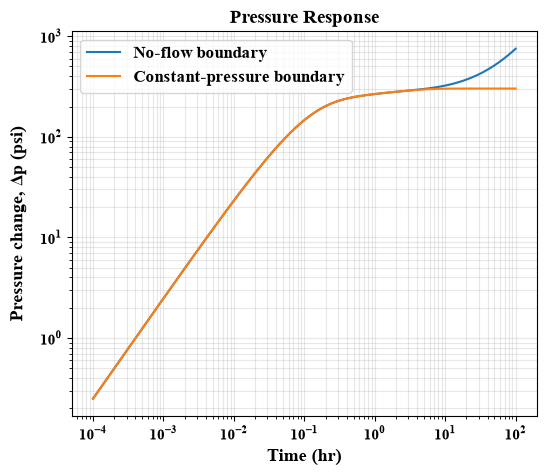

In [14]:
# ---- Pressure response ----
fig, ax = plt.subplots(figsize=(6, 5))

ax.loglog(
    time_dataset,
    rep_no_flow["delta_p_psi"],
    label="No-flow boundary"
)

ax.loglog(
    time_dataset,
    rep_constant_pressure["delta_p_psi"],
    label="Constant-pressure boundary"
)

ax.set_xlabel("Time (hr)", fontweight="bold", fontsize=13)
ax.set_ylabel("Pressure change, Δp (psi)", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Pressure Response", fontweight="bold", fontsize=14)

ax.legend()

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Pressure Response Plot.jpeg", dpi=300)

plt.show()

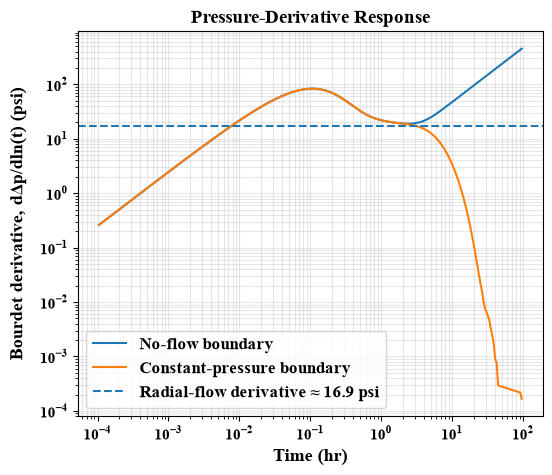

In [15]:
# ---- Bourdet derivative ----
fig, ax = plt.subplots(figsize=(6, 5))

for case, label in [
    (rep_no_flow, "No-flow boundary"),
    (rep_constant_pressure, "Constant-pressure boundary")
]:

    derivative = case["derivative_psi"]

    # Log scale requires positive derivative values
    mask = np.isfinite(derivative) & (derivative > 0)

    ax.loglog(
        time_dataset[mask],
        derivative[mask],
        label=label
    )

ax.set_xlabel("Time (hr)", fontweight="bold", fontsize=13)
ax.set_ylabel("Bourdet derivative, dΔp/dln(t) (psi)", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Pressure-Derivative Response", fontweight="bold", fontsize=14)

p_radial = 70.6 * q * mu * B / (
    representative_params["k_mD"] * h
)

ax.axhline(
    p_radial,
    linestyle="--",
    linewidth=1.5,
    label=f"Radial-flow derivative ≈ {p_radial:.1f} psi"
)

ax.legend()

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Bourdet Pressure-Derivative Response Plot.jpeg", dpi=300)

plt.show()

In [16]:
k_values = [20, 50, 100, 200]

k_sensitivity_cases = []

for k_value in k_values:

    row = pd.Series({
        "case_id": 10000 + k_value,
        "k_mD": float(k_value),
        "skin": 2.0,
        "C_bbl_per_psi": 0.010,
        "re_ft": 250.0,
        "boundary_type": "no_flow"
    })

    case = generate_one_case_fast(row)

    k_sensitivity_cases.append({
        "k_mD": k_value,
        "case": case
    })

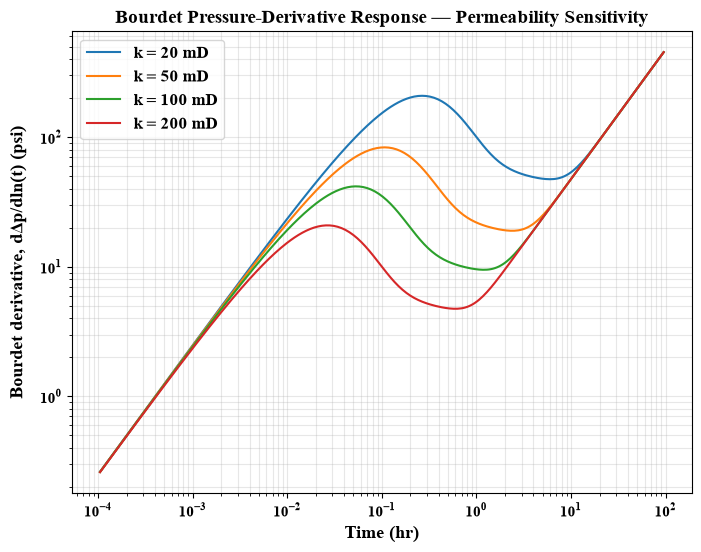

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

for item in k_sensitivity_cases:

    k_value = item["k_mD"]
    derivative = item["case"]["derivative_psi"]

    mask = np.isfinite(derivative) & (derivative > 0)

    ax.loglog(time_dataset[mask], derivative[mask], label=f"k = {k_value} mD")

ax.set_xlabel("Time (hr)", fontweight="bold", fontsize=13)
ax.set_ylabel("Bourdet derivative, dΔp/dln(t) (psi)", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Bourdet Pressure-Derivative Response — Permeability Sensitivity", fontweight="bold", fontsize=14)
ax.legend()

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Bourdet Pressure-Derivative Response_Permeability Sensitivity Plot.jpeg", dpi=300)

plt.show()

In [18]:
# -----------------------------
# Skin sensitivity
# -----------------------------

skin_values = [-2, 0, 2, 5]
skin_sensitivity_cases = []

for skin_value in skin_values:

    row = pd.Series({
        "case_id": 11000 + skin_value,
        "k_mD": 50.0,
        "skin": float(skin_value),
        "C_bbl_per_psi": 0.010,
        "re_ft": 250.0,
        "boundary_type": "no_flow"
    })

    case = generate_one_case_fast(row)

    skin_sensitivity_cases.append({
        "skin": skin_value,
        "case": case
    })


# -----------------------------
# Wellbore-storage sensitivity
# -----------------------------

C_values = [0.0025, 0.005, 0.010, 0.020]
C_sensitivity_cases = []

for i, C_value in enumerate(C_values):

    row = pd.Series({
        "case_id": 12000 + i,
        "k_mD": 50.0,
        "skin": 2.0,
        "C_bbl_per_psi": C_value,
        "re_ft": 250.0,
        "boundary_type": "no_flow"
    })

    case = generate_one_case_fast(row)

    C_sensitivity_cases.append({
        "C": C_value,
        "case": case
    })

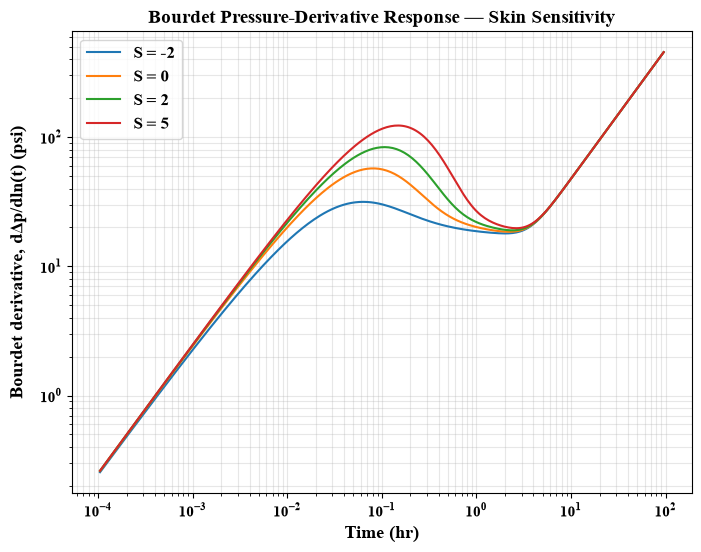

In [19]:
# =========================================================
# Skin sensitivity
# =========================================================

fig, ax = plt.subplots(figsize=(8, 6))

for item in skin_sensitivity_cases:

    derivative = item["case"]["derivative_psi"]

    mask = np.isfinite(derivative) & (derivative > 0)

    ax.loglog(time_dataset[mask], derivative[mask], label=f"S = {item['skin']}"    )

ax.set_xlabel("Time (hr)", fontweight="bold", fontsize=13)
ax.set_ylabel("Bourdet derivative, dΔp/dln(t) (psi)", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Bourdet Pressure-Derivative Response — Skin Sensitivity", fontweight="bold", fontsize=14)

ax.legend()

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Bourdet Pressure-Derivative Response_Skin Sensitivity Plot.jpeg", dpi=300)

plt.show()

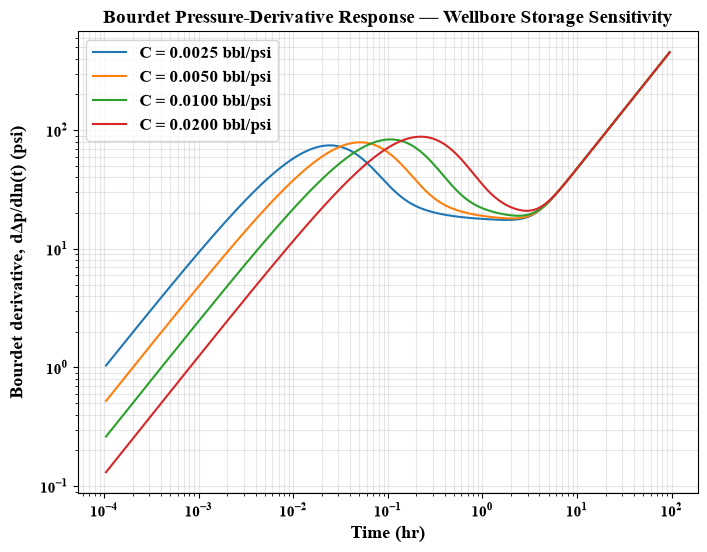

In [20]:
# =========================================================
# RIGHT: Wellbore-storage sensitivity
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))

for item in C_sensitivity_cases:

    derivative = item["case"]["derivative_psi"]

    mask = np.isfinite(derivative) & (derivative > 0)

    ax.loglog(
        time_dataset[mask],
        derivative[mask],
        label=f"C = {item['C']:.4f} bbl/psi"
    )

ax.set_xlabel("Time (hr)", fontweight="bold", fontsize=13)
ax.set_ylabel("Bourdet derivative, dΔp/dln(t) (psi)", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Bourdet Pressure-Derivative Response — Wellbore Storage Sensitivity", fontweight="bold", fontsize=14)

ax.legend()

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Bourdet Pressure-Derivative Response_Wellbore Storage Sensitivity Plot.jpeg", dpi=300)

plt.show()

## Cell 11 — Generate All 500 Clean Cases

In [21]:
clean_cases = []

for _, row in parameter_cases.iterrows():

    case = generate_one_case_fast(
        row
    )

    case["k_mD"] = float(
        row["k_mD"]
    )

    case["skin"] = float(
        row["skin"]
    )

    case["C_bbl_per_psi"] = float(
        row["C_bbl_per_psi"]
    )

    case["re_ft"] = float(
        row["re_ft"]
    )

    clean_cases.append(case)


print(
    "Generated cases:",
    len(clean_cases)
)

print(
    "Points per case:",
    len(time_dataset)
)

print(
    "Total transient points:",
    len(clean_cases)
    * len(time_dataset)
)

Generated cases: 500
Points per case: 290
Total transient points: 145000


# Freeze the Training/Test Cases

## Cell 12 — Space-Filling 100/400 Split

In [22]:
selection_features = [
    "k_mD",
    "skin",
    "C_bbl_per_psi",
    "re_ft"
]

selection_scaler = MinMaxScaler()

X_selection = (
    selection_scaler.fit_transform(
        parameter_cases[
            selection_features
        ]
    )
)

selection_df = (
    parameter_cases.copy()
)

for i, feature in enumerate(
    selection_features
):
    selection_df[
        f"{feature}_scaled"
    ] = X_selection[:, i]

# Cell 13 — Farthest-Point Selection

In [23]:
def farthest_point_selection(
    X,
    n_select,
    seed=42
):

    rng = np.random.default_rng(
        seed
    )

    selected = [
        rng.integers(len(X))
    ]

    min_dist = np.full(
        len(X),
        np.inf
    )

    for _ in range(
        1,
        n_select
    ):

        last = X[
            selected[-1]
        ]

        dist = np.linalg.norm(
            X - last,
            axis=1
        )

        min_dist = np.minimum(
            min_dist,
            dist
        )

        next_idx = np.argmax(
            min_dist
        )

        selected.append(
            next_idx
        )

    return selected

In [24]:
scaled_cols = [
    f"{x}_scaled"
    for x in selection_features
]

train_ids = []

for boundary in [
    "no_flow",
    "constant_pressure"
]:

    subset = selection_df[
        selection_df["boundary_type"]
        == boundary
    ].copy()

    X_sub = subset[
        scaled_cols
    ].to_numpy()

    selected_local = (
        farthest_point_selection(
            X_sub,
            n_select=50,
            seed=42
        )
    )

    selected_ids = (
        subset.iloc[selected_local]
        ["case_id"]
        .tolist()
    )

    train_ids.extend(
        selected_ids
    )

train_ids = set(train_ids)

train_params = parameter_cases[
    parameter_cases["case_id"].isin(
        train_ids
    )
].copy()

test_params = parameter_cases[
    ~parameter_cases["case_id"].isin(
        train_ids
    )
].copy()

print(
    "Training cases:",
    len(train_params)
)

print(
    "Testing cases:",
    len(test_params)
)

print("\nTraining boundary counts:")
print(
    train_params[
        "boundary_type"
    ].value_counts()
)

print("\nTesting boundary counts:")
print(
    test_params[
        "boundary_type"
    ].value_counts()
)

Training cases: 100
Testing cases: 400

Training boundary counts:
boundary_type
no_flow              50
constant_pressure    50
Name: count, dtype: int64

Testing boundary counts:
boundary_type
constant_pressure    208
no_flow              192
Name: count, dtype: int64


In [25]:
train_case_ids = sorted(
    train_params["case_id"].tolist()
)

test_case_ids = sorted(
    test_params["case_id"].tolist()
)

print(
    "Training cases:",
    len(train_case_ids)
)

print(
    "Testing cases:",
    len(test_case_ids)
)

Training cases: 100
Testing cases: 400


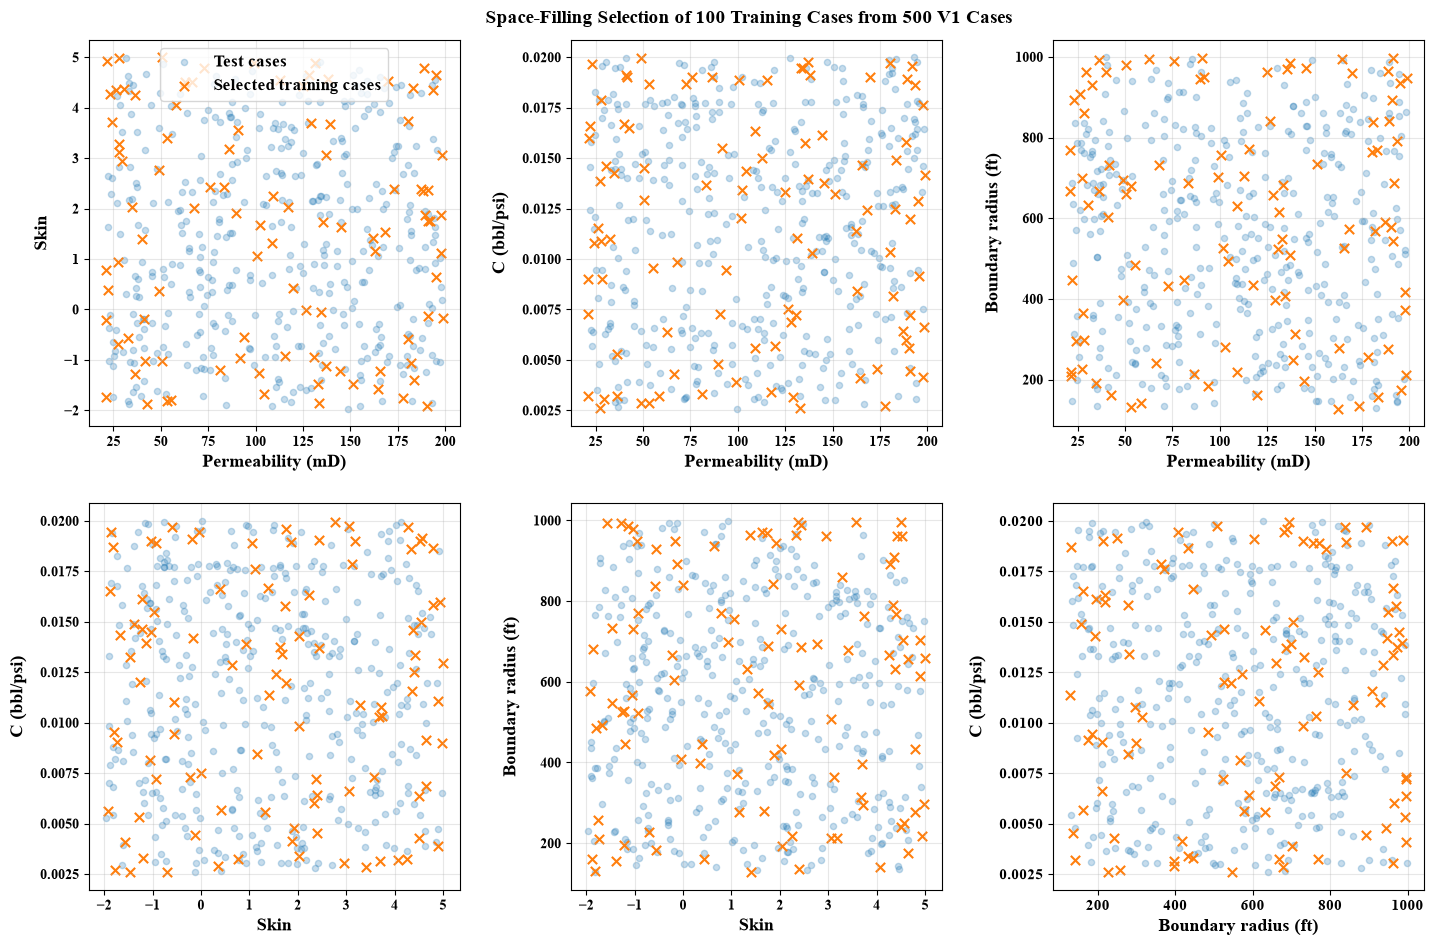

In [26]:
train_plot = parameter_cases[
    parameter_cases["case_id"].isin(train_case_ids)
]

test_plot = parameter_cases[
    parameter_cases["case_id"].isin(test_case_ids)
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(left=0.06, right=0.95, top=0.95, bottom=0.1, wspace=0.3)
pairs = [
    ("k_mD", "skin",
     "Permeability (mD)", "Skin"),

    ("k_mD", "C_bbl_per_psi",
     "Permeability (mD)", "C (bbl/psi)"),

    ("k_mD", "re_ft",
     "Permeability (mD)", "Boundary radius (ft)"),

    ("skin", "C_bbl_per_psi",
     "Skin", "C (bbl/psi)"),

    ("skin", "re_ft",
     "Skin", "Boundary radius (ft)"),

    ( "re_ft", "C_bbl_per_psi", "Boundary radius (ft)", "C (bbl/psi)", )
]

for ax, (x, y, xlabel, ylabel) in zip(axes.flat, pairs):

    ax.scatter(
        test_plot[x],
        test_plot[y],
        alpha=0.25,
        s=20,
        label="Test cases"
    )

    ax.scatter(
        train_plot[x],
        train_plot[y],
        s=45,
        marker="x",
        label="Selected training cases"
    )

    ax.set_xlabel(xlabel, fontweight="bold", fontsize=13)
    ax.set_ylabel(ylabel, fontweight="bold", fontsize=13, labelpad=10)
    ax.grid(True, which="both", alpha=0.3)

axes[0, 0].legend()

fig.suptitle("Space-Filling Selection of 100 Training Cases from 500 V1 Cases", fontweight="bold", fontsize=14)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Space-Filling Selection of 100 Training Cases from 500 V1 Cases Plot.jpeg", dpi=300)
# fig.tight_layout()
plt.show()

# Convert Clean Data to Observed Data

## Cell 14 — Add Pressure Noise and Smooth the Transients

In [27]:
sigma_abs = 0.02
relative_fraction = 0.001

observed_cases = []

for case in clean_cases:

    p_clean = case[
        "delta_p_psi"
    ]

    rng = np.random.default_rng(
        1000 + case["case_id"]
    )

    sigma_pressure = np.sqrt(
        sigma_abs**2
        +
        (
            relative_fraction
            * p_clean
        )**2
    )

    p_noisy = (
        p_clean
        + rng.normal(
            0.0,
            sigma_pressure
        )
    )

    p_smooth = savgol_filter(
        p_noisy,
        window_length=21,
        polyorder=2
    )

    d_observed = (
        bourdet_derivative(
            p_smooth,
            time_dataset
        )
    )

    observed_cases.append({
        "case_id":
            case["case_id"],

        "boundary_type":
            case["boundary_type"],

        "k_mD":
            case["k_mD"],

        "skin":
            case["skin"],

        "C_bbl_per_psi":
            case["C_bbl_per_psi"],

        "re_ft":
            case["re_ft"],

        "pressure_clean":
            p_clean.copy(),

        "pressure_noisy":
            p_noisy,

        "pressure_smoothed":
            p_smooth,

        "derivative_clean":
            case[
                "derivative_psi"
            ].copy(),

        "derivative_observed":
            d_observed,

        "noise_sigma":
            sigma_pressure
    })

## Cell 15 — Final Observed-Data QC

In [28]:
print(
    "Cases:",
    len(observed_cases)
)

print(
    "All smoothed pressures finite:",
    all(
        np.all(
            np.isfinite(
                c["pressure_smoothed"]
            )
        )
        for c in observed_cases
    )
)

print(
    "All interior derivatives finite:",
    all(
        np.all(
            np.isfinite(
                c["derivative_observed"][1:-1]
            )
        )
        for c in observed_cases
    )
)

Cases: 500
All smoothed pressures finite: True
All interior derivatives finite: True


In [29]:
# ---------------------------------------------------------
# Separate observed cases into the frozen V1 train/test split
# ---------------------------------------------------------

train_id_set = set(train_case_ids)
test_id_set = set(test_case_ids)

train_observed_cases = [
    case for case in observed_cases
    if case["case_id"] in train_id_set
]

test_observed_cases = [
    case for case in observed_cases
    if case["case_id"] in test_id_set
]

print("Training cases:", len(train_observed_cases))
print("Testing cases :", len(test_observed_cases))

Training cases: 100
Testing cases : 400


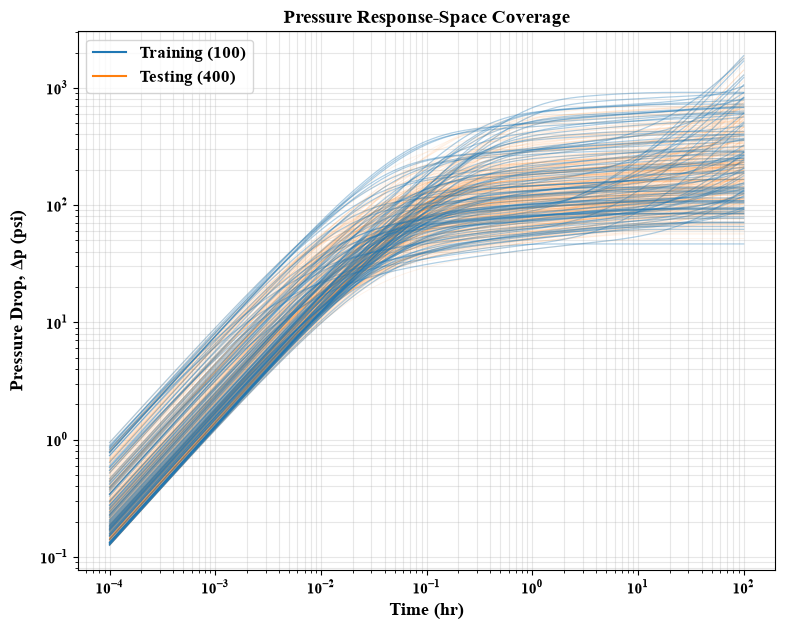

In [30]:
fig, ax = plt.subplots(figsize=(9, 7))

# Plot testing cases first
for i, case in enumerate(test_observed_cases):

    ax.loglog(
        time_dataset,
        case["pressure_clean"],
        color="tab:orange",
        alpha=0.08,
        linewidth=0.7
    )


# Plot training cases on top
for i, case in enumerate(train_observed_cases):

    ax.loglog(
        time_dataset,
        case["pressure_clean"],
        color="tab:blue",
        alpha=0.35,
        linewidth=0.9
    )

# Legend
ax.plot(
    [], [],
    color="tab:blue",
    label="Training (100)"
)

ax.plot(
    [], [],
    color="tab:orange",
    label="Testing (400)"
)

ax.set_xlabel("Time (hr)", fontweight="bold", fontsize=13)

ax.set_ylabel("Pressure Drop, Δp (psi)", fontweight="bold", fontsize=13, labelpad=10)

ax.set_title("Pressure Response-Space Coverage", fontweight="bold", fontsize=14)

ax.legend()

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Pressure Response-Space Coverage Plot.jpeg", dpi=300)

plt.show()

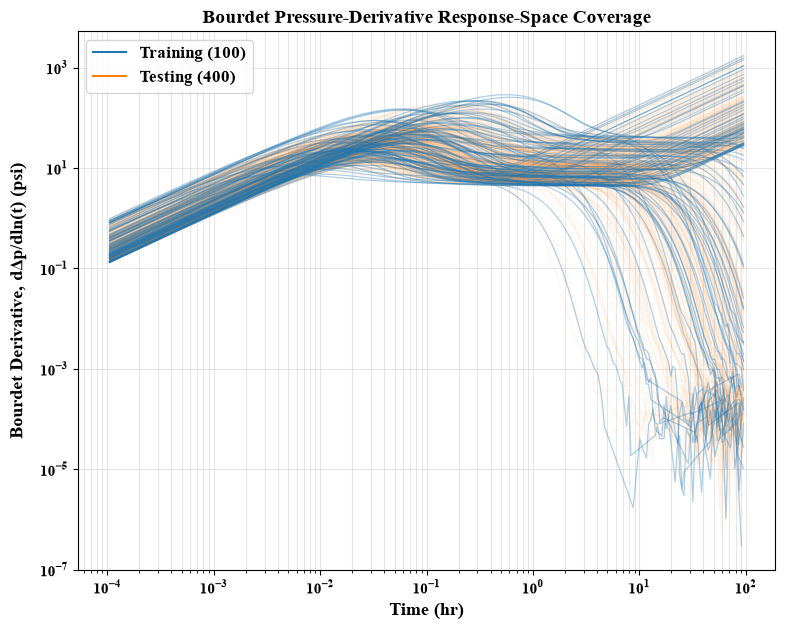

In [31]:
fig, ax = plt.subplots(figsize=(9, 7))

# ---------------------------------------------------------
# Testing cases
# ---------------------------------------------------------

for i, case in enumerate(test_observed_cases):

    derivative = case["derivative_clean"]

    mask = (
        np.isfinite(derivative)
        & (derivative > 0)
    )

    ax.loglog(
        time_dataset[mask],
        derivative[mask],
        color="tab:orange",
        alpha=0.08,
        linewidth=0.7)


# ---------------------------------------------------------
# Training cases
# ---------------------------------------------------------

for i, case in enumerate(train_observed_cases):

    derivative = case["derivative_clean"]

    mask = (
        np.isfinite(derivative)
        & (derivative > 0)
    )

    ax.loglog(
        time_dataset[mask],
        derivative[mask],
        color="tab:blue",
        alpha=0.35,
        linewidth=0.9)

ax.plot(
    [], [],
    color="tab:blue",
    label="Training (100)"
)

ax.plot(
    [], [],
    color="tab:orange",
    label="Testing (400)"
)

ax.set_xlabel("Time (hr)", fontweight="bold", fontsize=13)
ax.set_ylabel("Bourdet Derivative, dΔp/dln(t) (psi)", fontweight="bold", fontsize=13, labelpad=10)

ax.set_title("Bourdet Pressure-Derivative Response-Space Coverage", fontweight="bold", fontsize=14)

ax.legend()

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Bourdet Pressure-Derivative Response-Space Coverage Plot.jpeg", dpi=300)

plt.show()

In [32]:
# Select one representative processed case
example_case = observed_cases[0]

p_clean = example_case["pressure_clean"]
p_noisy = example_case["pressure_noisy"]
p_smooth = example_case["pressure_smoothed"]

d_clean = example_case["derivative_clean"]
d_smooth = example_case["derivative_observed"]

# What would happen if we differentiated noisy pressure directly?
d_noisy = bourdet_derivative(
    p_noisy,
    time_dataset
)

print("Case ID:", example_case["case_id"])
print("k =", example_case["k_mD"], "mD")
print("Skin =", example_case["skin"])
print("C =", example_case["C_bbl_per_psi"], "bbl/psi")
print("Boundary =", example_case["boundary_type"])

Case ID: 0
k = 87.41722139252525 mD
Skin = 2.8871319981382157
C = 0.005739826254675845 bbl/psi
Boundary = constant_pressure


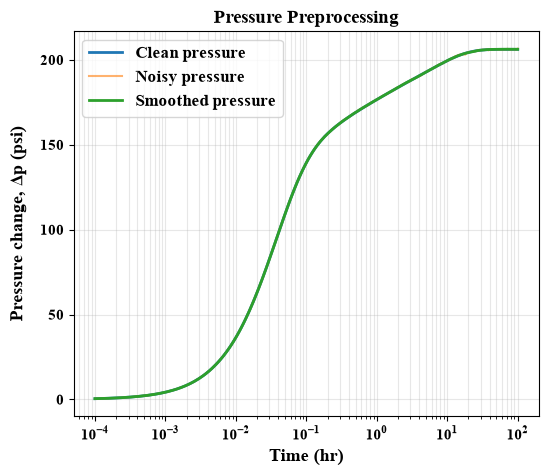

In [33]:
# =========================================================
# LEFT: Pressure preprocessing
# =========================================================

fig, ax = plt.subplots(figsize=(6, 5))

ax.semilogx(
    time_dataset,
    p_clean,
    label="Clean pressure",
    linewidth=2
)

ax.semilogx(
    time_dataset,
    p_noisy,
    label="Noisy pressure",
    alpha=0.6
)

ax.semilogx(
    time_dataset,
    p_smooth,
    label="Smoothed pressure",
    linewidth=2
)

ax.set_xlabel("Time (hr)", fontweight="bold", fontsize=13)
ax.set_ylabel("Pressure change, Δp (psi)", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Pressure Preprocessing", fontweight="bold", fontsize=14)

ax.legend()

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Pressure Preprocessing Plot.jpeg", dpi=300)

plt.show()

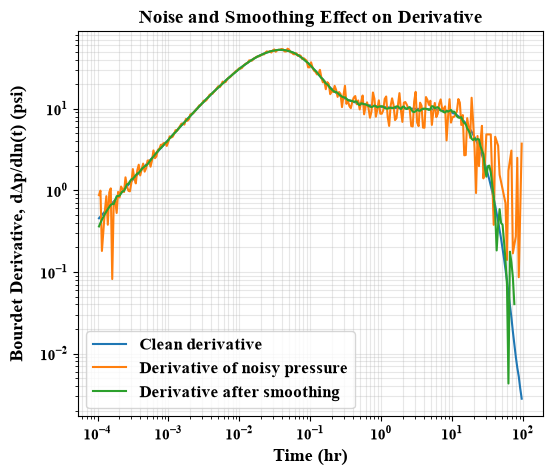

In [34]:
# =========================================================
# RIGHT: Effect on Bourdet derivative
# =========================================================

fig, ax = plt.subplots(figsize=(6, 5))

for derivative, label in [
    (d_clean, "Clean derivative"),
    (d_noisy, "Derivative of noisy pressure"),
    (d_smooth, "Derivative after smoothing")
]:

    mask = (
        np.isfinite(derivative)
        & (derivative > 0)
    )

    ax.loglog(
        time_dataset[mask],
        derivative[mask],
        label=label
    )

ax.set_xlabel("Time (hr)", fontweight="bold", fontsize=13)

ax.set_ylabel("Bourdet Derivative, dΔp/dln(t) (psi)", fontweight="bold", fontsize=13, labelpad=10)

ax.set_title("Noise and Smoothing Effect on Derivative", fontweight="bold", fontsize=14)

ax.legend()

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Noise and Smoothing Effect on Derivative Plot.jpeg", dpi=300)

plt.show()

# Final Feature Extraction
## Cell 16 — Fixed Feature Times and Log-Time Interpolation

In [35]:
feature_times = np.array([
    0.01,
    0.03,
    0.1,
    0.5,
    1.0,
    3.0,
    10.0,
    30.0
])


def interpolate_log_time(
    time,
    values,
    target_times
):

    return np.interp(
        np.log10(target_times),
        np.log10(time),
        values
    )

## Cell 17 — Build the ML Feature Table

In [36]:
feature_rows = []

for case in observed_cases:

    p_features = (
        interpolate_log_time(
            time_dataset,
            case[
                "pressure_smoothed"
            ],
            feature_times
        )
    )

    d_features = (
        interpolate_log_time(
            time_dataset,
            case[
                "derivative_observed"
            ],
            feature_times
        )
    )

    row = {
        "case_id":
            case["case_id"]
    }

    for t, value in zip(
        feature_times,
        p_features
    ):
        row[
            f"P_{t:g}hr"
        ] = value

    for t, value in zip(
        feature_times,
        d_features
    ):
        row[
            f"D_{t:g}hr"
        ] = value

    row["k_mD"] = (
        case["k_mD"]
    )

    row["skin"] = (
        case["skin"]
    )

    feature_rows.append(row)


feature_df = pd.DataFrame(
    feature_rows
)

print(
    "Feature table shape:",
    feature_df.shape
)

Feature table shape: (500, 19)


## Cell 18 — Final Baseline X and y

In [37]:
feature_columns = [
    col
    for col in feature_df.columns
    if (
        col.startswith("P_")
        or col.startswith("D_")
    )
]

target_columns = [
    "k_mD",
    "skin"
]

X = feature_df[
    feature_columns
].copy()

y = feature_df[
    target_columns
].copy()

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "\nFeatures:"
)

print(
    feature_columns
)

print(
    "\nTargets:"
)

print(
    target_columns
)

X shape: (500, 16)
y shape: (500, 2)

Features:
['P_0.01hr', 'P_0.03hr', 'P_0.1hr', 'P_0.5hr', 'P_1hr', 'P_3hr', 'P_10hr', 'P_30hr', 'D_0.01hr', 'D_0.03hr', 'D_0.1hr', 'D_0.5hr', 'D_1hr', 'D_3hr', 'D_10hr', 'D_30hr']

Targets:
['k_mD', 'skin']


## Cell 19 — Save the ML-ready dataset

In [38]:
ml_dataset = feature_df.copy()

train_id_set = set(train_case_ids)

ml_dataset["split"] = np.where(
    ml_dataset["case_id"].isin(train_id_set),
    "train",
    "test"
)

ml_dataset.to_csv(
    "well_test_ml_dataset.csv",
    index=False
)

print(ml_dataset.shape)
print(ml_dataset["split"].value_counts())

(500, 20)
split
test     400
train    100
Name: count, dtype: int64


## Cell 20 — Save the processed transients

In [39]:
np.savez_compressed(
    "well_test_processed_transients.npz",

    case_id=np.array([
        c["case_id"]
        for c in observed_cases
    ]),

    time_hr=time_dataset,

    pressure_clean=np.array([
        c["pressure_clean"]
        for c in observed_cases
    ]),

    pressure_noisy=np.array([
        c["pressure_noisy"]
        for c in observed_cases
    ]),

    pressure_smoothed=np.array([
        c["pressure_smoothed"]
        for c in observed_cases
    ]),

    derivative_clean=np.array([
        c["derivative_clean"]
        for c in observed_cases
    ]),

    derivative_observed=np.array([
        c["derivative_observed"]
        for c in observed_cases
    ])
)